In [6]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from astropy.table import Table, join, hstack
from astropy.io import fits
import tomllib

In [11]:
# Load the tables from the catalog filder
def load_catalogs(gal, band, cat_dir):
    catalog = Table.read(f"{cat_dir}{gal}_jwst_{band}_cat.fits")
    return catalog

50000
['id', 'xcenter', 'ycenter', 'aperture_sum', 'flux', 'sharpness', 'roundness', 'finder_mag', 'peak', 'ra', 'dec', 'finder_flux_abmag', 'aperture_sum_abmag']
  id       xcenter       ... finder_flux_abmag  aperture_sum_abmag
----- ------------------ ... ------------------ ------------------
42264  4474.109076454452 ...  25.82090579092968                 --
40723  3803.934423709494 ...   25.8040293579801                 --
 5630  2817.081910363426 ... 24.748209462937677                 --
44611  4504.288971844953 ...  25.84621486442916                 --
14794 3779.0924443064728 ...  25.36009518898704                 --
19952  5741.336507797289 ... 25.495442043613945                 --
20208 3210.1706786056366 ... 25.501593070396446                 --
22570 1645.1063092784866 ... 25.548473514156676                 --
22953 1324.5784570046367 ... 25.555363317623538                 --
 1135 2251.7065298768352 ... 23.458003828947067                 --
  ...                ... ...     

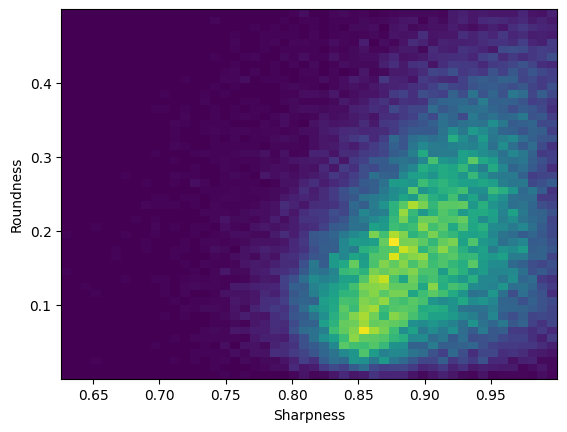

In [21]:
config_file = '/nexus/posix0/MIA-astro-env/eschinner/reho/centres/jwst_aperture_photometry/config/config.toml'     # Photometry parameters
local_file = '/nexus/posix0/MIA-astro-env/eschinner/reho/centres/jwst_aperture_photometry/config/local.toml'        # Paths to directories

def load_config(config_path: str) -> dict:
    with open(config_path, "rb") as f:
        return tomllib.load(f)

# Unpack the parameters from the config file
conf = load_config(config_file)
local = load_config(local_file)
gal = conf['targets'][0]
band = conf['bands'][0]
cat_dir = local['out_dir']

catalog = load_catalogs(gal, band, cat_dir)
print(len(catalog))
print(catalog.colnames)
print(catalog)

fig, ax = plt.subplots()
x = catalog['sharpness']
y = catalog['roundness']
ax.hist2d(x, y, bins=50)
ax.set_xlabel('Sharpness')
ax.set_ylabel('Roundness')
plt.show()